# Dataset Loading

## Observation

The HR Analytics dataset is loaded into a Pandas DataFrame using the read_csv() function. This allows the dataset to be stored in a structured tabular format where each column represents a feature and each row represents an employee record.

The dataset will be used to perform Exploratory Data Analysis (EDA) to understand feature distributions and identify factors that may influence employee promotion.

In [69]:
import pandas as pd
df = pd.read_csv("train.csv")
df


,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54803,3030,Technology,region_14,Bachelor's,m,sourcing,1,48,3.0,17,0,78,0
54804,74592,Operations,region_27,Master's & above,f,other,1,37,2.0,6,0,56,0
54805,13918,Analytics,region_1,Bachelor's,m,other,1,27,5.0,3,0,79,0
54806,13614,Sales & Marketing,region_9,NaN,m,sourcing,1,29,1.0,2,0,45,0


# Step1: Dataset Information 


 Observation

 The df.info() function provides an overview of the dataset structure, including the total number of entries, column names, data types, and the count of non-null values.
   From this step, we can identify:
       which features are numerical
       which features are categorical
       whether missing values exist in any columns

As the Understanding the dataset schema is essential before performing further EDA or preprocessing steps.

In [70]:

df.info()   #tells you all the info about it 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won?           54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 5.4+ MB


# Assumption :

Columns with missing values may require imputation techniques before training machine learning models.

In [71]:
df.nunique()

employee_id             54808
department                  9
region                     34
education                   3
gender                      2
recruitment_channel         3
no_of_trainings            10
age                        41
previous_year_rating        5
length_of_service          35
awards_won?                 2
avg_training_score         61
is_promoted                 2
dtype: int64

# Step-2: Dataset Shape

Observation:

The dataset contains 54,808 records and 14 features.
Each row represents an individual employee, and each column represents an attribute describing the employee.

This indicates that the dataset has a moderate number of observations and features, which is suitable for performing exploratory data analysis and building machine learning models.

In [72]:
df.shape

(54808, 13)

## Assumption

Since the dataset contains multiple employee attributes, some of these features may influence the promotion outcome (is_promoted), which will be explored further during EDA.


# Step3: Dataset Preview

Observation:

The df.head() function is used to display the first few rows of the dataset.
This provides a quick preview of the dataset structure, allowing us to verify that the data has been loaded correctly and that the columns contain meaningful values.

From this preview, we can observe that each row represents an individual employee record, while each column represents a specific attribute such as department, education, age, training score, and promotion status.

In [73]:
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


Assumption

Based on the dataset preview, it appears that the dataset contains both categorical and numerical features, which will require different preprocessing techniques during further analysis.

# Step4: Statistical Summary of Numerical Features

Observation:
The describe() function provides statistical summaries for all numerical features in the dataset. These statistics include count, mean, standard deviation, minimum, maximum, and quartile values.

From this summary, we can observe the range and distribution of key numerical variables such as age, number of trainings, length of service, previous year rating, and average training score.

These statistics help in identifying data spread, potential outliers, and general trends within the dataset.

In [74]:
df.describe()  #only describess the numerical values 

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,99.000000,1.000000


Assumption:
Features such as average training score, previous year rating, and length of service may have a potential influence on the promotion outcome, which will be further analyzed through visualization and correlation analysis.

Observation

The describe(include="all") function provides a comprehensive statistical summary of both numerical and categorical features in the dataset.

For categorical variables, it shows the number of unique categories, the most frequent category (top), and its frequency (freq). This helps in identifying dominant categories within features such as department, education, gender, and recruitment channel.

In [75]:
df.describe(include="all")  #describes all the features 

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808,54808,52399,54808,54808,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000
unique,NaN,9,34,3,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Sales & Marketing,region_2,Bachelor's,m,other,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,16840,12343,36669,38496,30446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,39195.830627,NaN,NaN,NaN,NaN,NaN,1.253011,34.803915,3.329256,5.865512,0.023172,63.386750,0.085170
std,22586.581449,NaN,NaN,NaN,NaN,NaN,0.609264,7.660169,1.259993,4.265094,0.150450,13.371559,0.279137
min,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,20.000000,1.000000,1.000000,0.000000,39.000000,0.000000
25%,19669.750000,NaN,NaN,NaN,NaN,NaN,1.000000,29.000000,3.000000,3.000000,0.000000,51.000000,0.000000
50%,39225.500000,NaN,NaN,NaN,NaN,NaN,1.000000,33.000000,3.000000,5.000000,0.000000,60.000000,0.000000
75%,58730.500000,NaN,NaN,NaN,NaN,NaN,1.000000,39.000000,4.000000,7.000000,0.000000,76.000000,0.000000


Assumption

Some categorical variables, such as department, education level, and recruitment channel, may play a role in influencing employee promotion decisions. These relationships will be explored further through visualization and statistical analysis.

# step5: Missing Value Analysis


Observation:

The df.isnull().sum() function is used to identify the number of missing values present in each feature of the dataset. Detecting missing values is an important step in exploratory data analysis because incomplete data can affect model performance and analysis results.

From this analysis, we can determine which features contain missing values and require preprocessing before further analysis.

In [76]:
df.isnull().sum()  #checks the counts of null values of the features 

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

Assumption

Features with missing values may require imputation techniques such as mean, median, or mode replacement, depending on whether the variable is numerical or categorical.

Inference

Handling missing values appropriately is necessary to ensure data quality and reliable machine learning model performance.

# Step6: Duplicate Record Check

Observation: 
The df.duplicated().sum() function is used to identify the number of duplicate rows present in the dataset. Duplicate records can negatively affect data analysis and machine learning models by introducing redundant information.

From this check, we can determine whether the dataset contains repeated employee records that may require removal.

In [77]:
df.duplicated().sum() # for checking any duplicates

np.int64(0)

Assumption:

Since the dataset does not contain duplicate rows, we can assume that each record corresponds to a distinct employee instance and no further duplicate removal is required.

Inference:

The absence of duplicate records ensures that the dataset is consistent and suitable for further exploratory data analysis and modeling without requiring duplicate data cleaning.

# Step 7: Target Variable Distribution

Observation

The distribution of the target variable (is_promoted) shows that the majority of employees in the dataset are not promoted. Approximately 91% of employees are not promoted, while only about 9% are promoted.

This indicates that the dataset is highly imbalanced, with significantly fewer instances of promoted employees.

In [78]:
df['is_promoted'].value_counts(normalize=True) #0 means they are not promoted and 1 means yes they are promoted and normalize give you the % distribution

is_promoted
0    0.91483
1    0.08517
Name: proportion, dtype: float64

Assumption

Since promotions are relatively rare events in organizations, the dataset reflects a natural class imbalance where only a small proportion of employees receive promotions.

Inference

The presence of class imbalance may affect machine learning model performance. Therefore, appropriate techniques such as class balancing or resampling methods may be required during model training.

# Target Variable Visualization

Observation

A count plot of the target variable (is_promoted) shows a strong imbalance between the two classes. The majority of employees belong to the not promoted (0) category, while only a small proportion belong to the promoted (1) category.

This confirms the imbalance previously observed from the percentage distribution.

/tmp/ipykernel_45374/1145795796.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_promoted', data=df, palette='viridis')


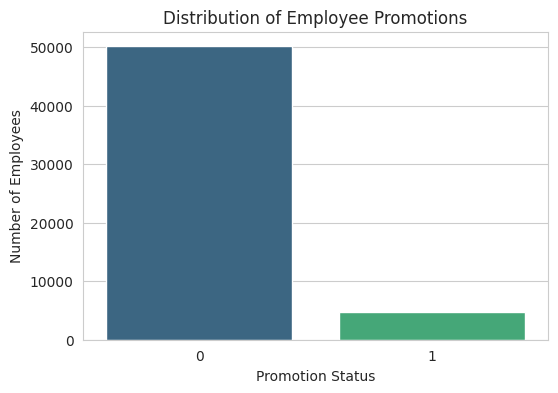

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x='is_promoted', data=df, palette='viridis')

plt.title("Distribution of Employee Promotions")
plt.xlabel("Promotion Status")
plt.ylabel("Number of Employees")

plt.show()

# Step8: Univariate analysis


Observation

Numerical features in the dataset were identified using the select_dtypes() function. This step helps separate numerical variables from categorical variables so that appropriate analysis techniques can be applied.

The employee_id column represents a unique identifier assigned to each employee and does not provide meaningful information for analysis.

In [80]:
num_cols = df.select_dtypes(include = "number").columns.tolist()
num_cols.remove('employee_id')
num_cols


['no_of_trainings',
 'age',
 'previous_year_rating',
 'length_of_service',
 'awards_won?',
 'avg_training_score',
 'is_promoted']

Assumption

Numerical features such as age, number of trainings, previous year rating, length of service, and average training score may contain patterns that influence employee promotion outcomes.

Inference

These numerical features will be analyzed individually during the univariate analysis stage to understand their distribution, spread, and potential outliers.
Since identifiers do not contribute to predictive patterns, the employee_id column is removed from the numerical feature list to ensure that further analysis focuses only on relevant variables.

# Visualization

Observation:

Histograms were generated for all numerical variables to understand their distributions and identify potential patterns. Most employees have 1–2 trainings, and the workforce is concentrated in the 28–40 age range. The majority of employees have less than 10 years of service, indicating that long-tenured employees are relatively rare.

Performance-related variables such as previous year rating and average training score show clustered distributions, suggesting varying levels of employee performance.

Additionally, the awards_won variable is highly imbalanced, with only a small fraction of employees receiving awards.

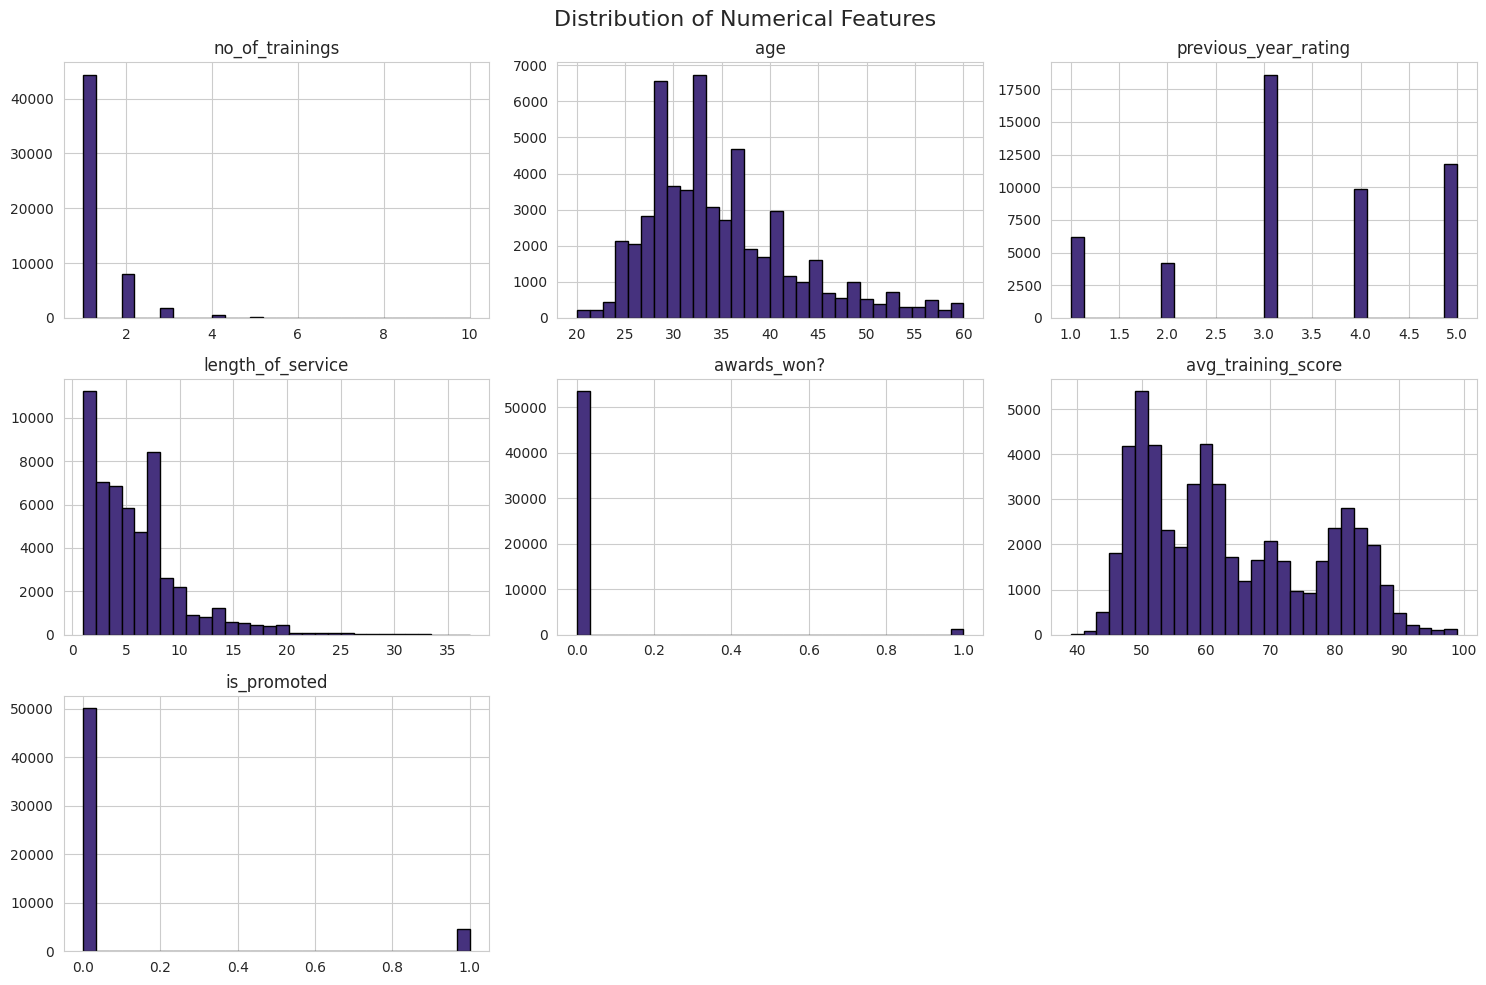

In [81]:
import matplotlib.pyplot as plt
df[num_cols].hist(figsize=(15,10), bins=30, edgecolor='black')
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

# Step9: Outlier Detection using Boxplots

Observation

Boxplots were used to detect potential outliers and examine the spread of numerical features. Several variables show extreme values outside the whiskers.

Notable outliers appear in no_of_trainings, age, and length_of_service, where a small number of employees have unusually high values compared to the majority. The length_of_service feature in particular exhibits significant right-skewness, with some employees having very long tenure.

The avg_training_score feature contains a few high-value observations, while awards_won is highly imbalanced with most employees having no awards.

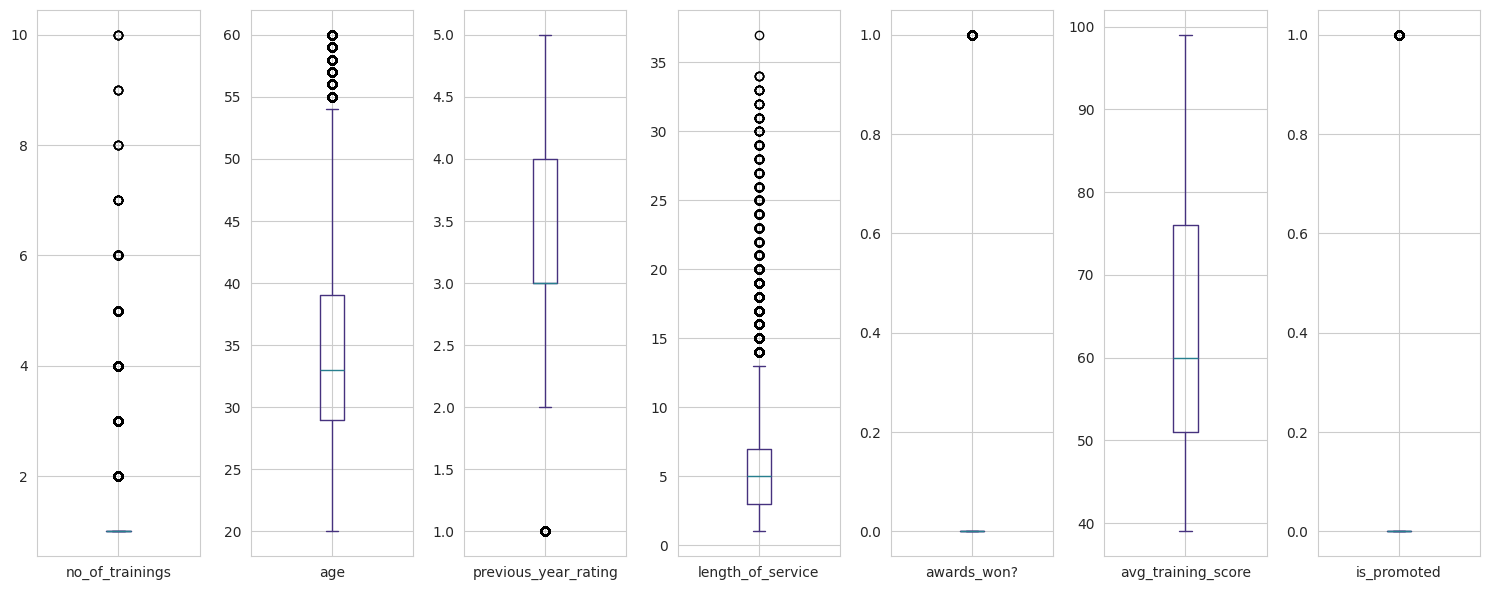

In [82]:
df[num_cols].plot(kind='box', subplots=True, figsize=(15, 6))  #box plot of detecting the outliers and the spread of the data 
plt.tight_layout()
plt.show()


Inference: 
Outliers will be further evaluated during preprocessing to determine whether they should be retained, transformed, or treated using robust modeling techniques.

# Step 10: Identification of Categorical Features

Observation

Categorical features were identified using the select_dtypes() function. These variables represent attributes such as department, region, education level, gender, and recruitment channel.

In [83]:
cat_cols = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist() # for categorical data 
cat_cols

['department', 'region', 'education', 'gender', 'recruitment_channel']

In [84]:
for col in cat_cols:   #each categorical column will be analysed uniquely 
    print(f'--- {col} ---')
    print(df[col].value_counts())
    print(f'Unique values: {df[col].nunique()}')
    print()

--- department ---
department
Sales & Marketing    16840
Operations           11348
Technology            7138
Procurement           7138
Analytics             5352
Finance               2536
HR                    2418
Legal                 1039
R&D                    999
Name: count, dtype: int64
Unique values: 9

--- region ---
region
region_2     12343
region_22     6428
region_7      4843
region_15     2808
region_13     2648
region_26     2260
region_31     1935
region_4      1703
region_27     1659
region_16     1465
region_28     1318
region_11     1315
region_23     1175
region_29      994
region_32      945
region_19      874
region_20      850
region_14      827
region_25      819
region_17      796
region_5       766
region_6       690
region_30      657
region_8       655
region_10      648
region_1       610
region_24      508
region_12      500
region_9       420
region_21      411
region_3       346
region_34      292
region_33      269
region_18       31
Name: count, dt

Observation

Count plots were generated for all categorical variables to examine the distribution of categories within each feature. These plots illustrate the frequency of different categories for attributes such as department, region, education, gender, and recruitment channel.

From these visualizations, we can observe how employees are distributed across different departments, geographic regions, education levels, and recruitment channels.

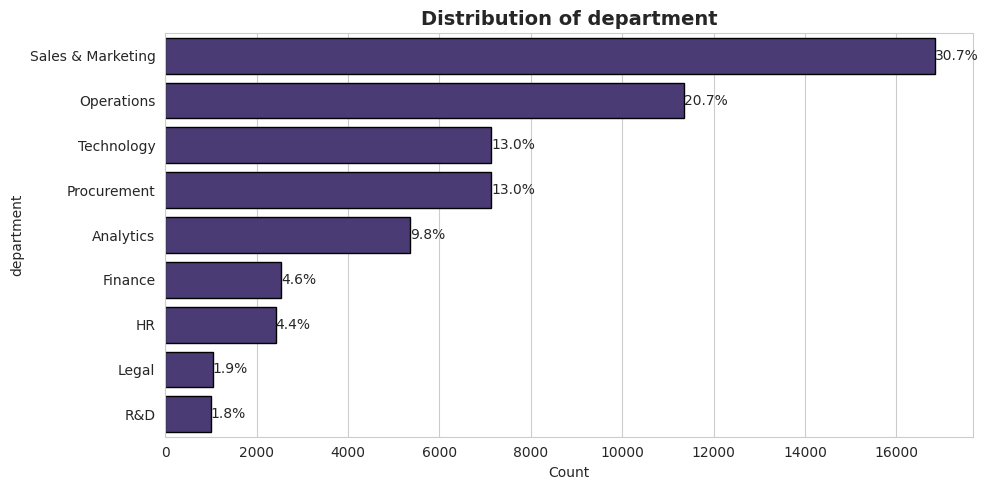

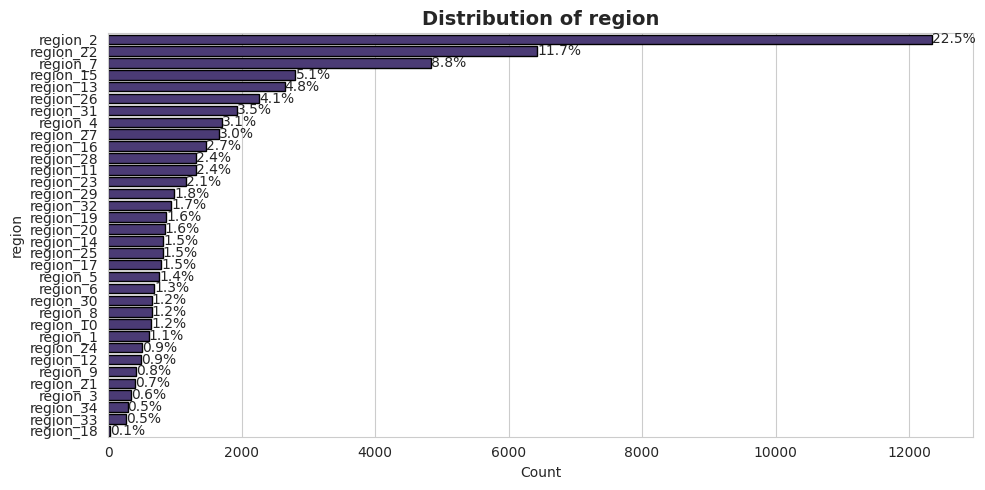

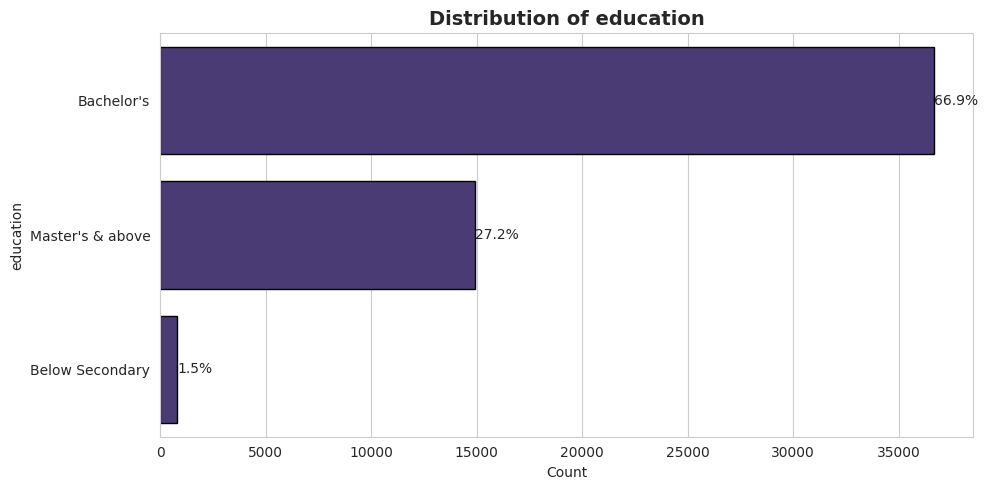

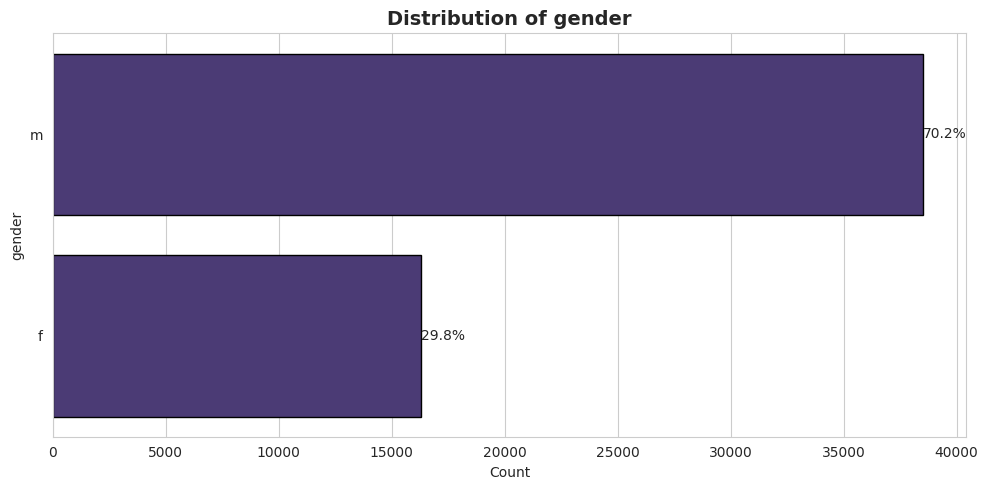

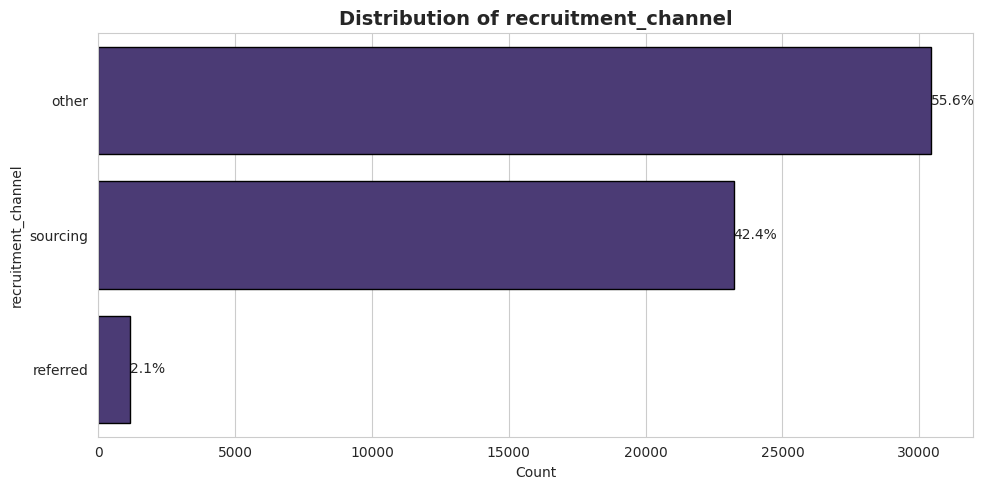

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

# Global styling
sns.set_style("whitegrid")
sns.set_palette("viridis")

for col in cat_cols:
    
    plt.figure(figsize=(10,5))

    ax = sns.countplot(
        data=df,
        y=col,
        order=df[col].value_counts().index,
        edgecolor="black"
    )

    plt.title(f"Distribution of {col}", fontsize=14, fontweight='bold')
    plt.xlabel("Count")
    plt.ylabel(col)

    # Add percentage labels
    total = len(df)
    for p in ax.patches:
        percentage = f'{100 * p.get_width()/total:.1f}%'
        ax.annotate(
            percentage,
            (p.get_width(), p.get_y() + p.get_height()/2),
            ha='left',
            va='center'
        )

    plt.tight_layout()
    plt.show()

Inference

Understanding the distribution of categorical variables helps identify potential patterns and imbalances that may affect employee promotion predictions.

# Step10 : Skewness Analysis of Numerical Features

Observation

The skewness of numerical features was calculated to understand the symmetry of their distributions. Skewness values close to zero indicate approximately symmetric distributions, while larger positive or negative values indicate skewed distributions.

Some variables such as no_of_trainings and length_of_service exhibit positive skewness, indicating that a large number of employees have lower values with a few extreme high values.

In [86]:
print(df[num_cols].skew()) # for skewness -0.5 - 0.5 is ok, 0.5-1.0 is moderate skew , skew>1.0 means should perform transformation


no_of_trainings         3.445434
age                     1.007432
previous_year_rating   -0.310638
length_of_service       1.738061
awards_won?             6.338914
avg_training_score      0.451908
is_promoted             2.972339
dtype: float64


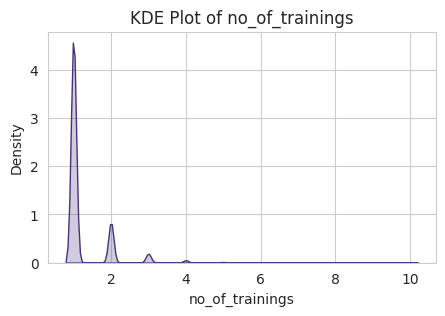

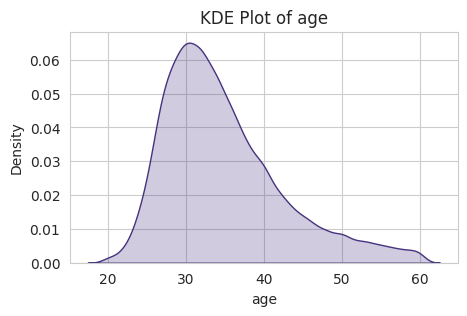

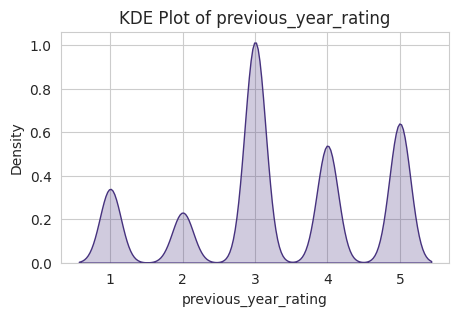

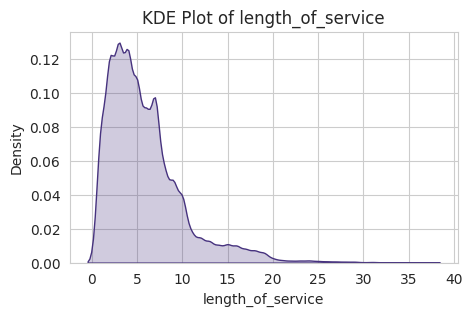

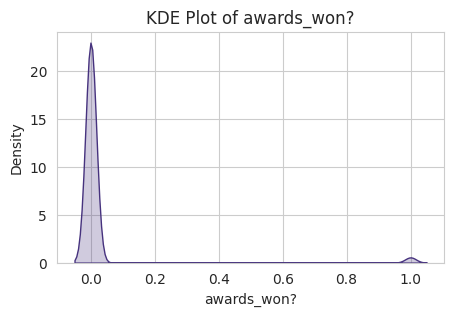

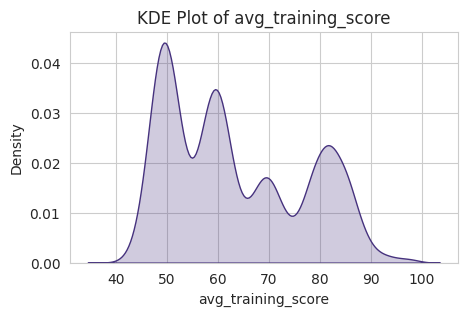

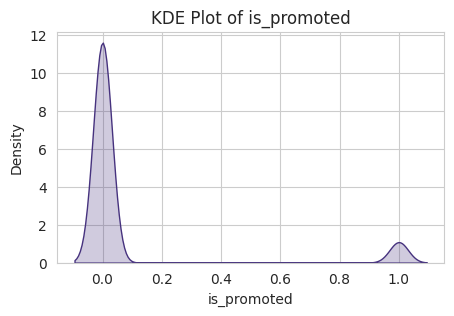

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.kdeplot(df[col], fill=True)
    plt.title(f"KDE Plot of {col}")
    plt.show()

Assumption

The observed skewness may occur because most employees participate in few training programs and have relatively shorter tenure, while only a small number of employees have significantly higher values.

Inference

Highly skewed features may require transformation techniques such as log or square-root transformation if certain machine learning models sensitive to skewness are used.

# Step11: Bivariate Analysis: Numerical Features vs Promotion


Observation

Boxplots were used to analyze the relationship between numerical features and the promotion outcome. The distributions indicate noticeable differences between promoted and non-promoted employees for certain variables.

Employees who were promoted generally exhibit higher average training scores and higher previous year ratings, suggesting that performance-related metrics may strongly influence promotion decisions.
However, the number of trainings attended does not appear to show a strong difference between promoted and non-promoted employees, suggesting that the quantity of training programs alone may not significantly impact promotion outcomes.

/tmp/ipykernel_45374/3064819863.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


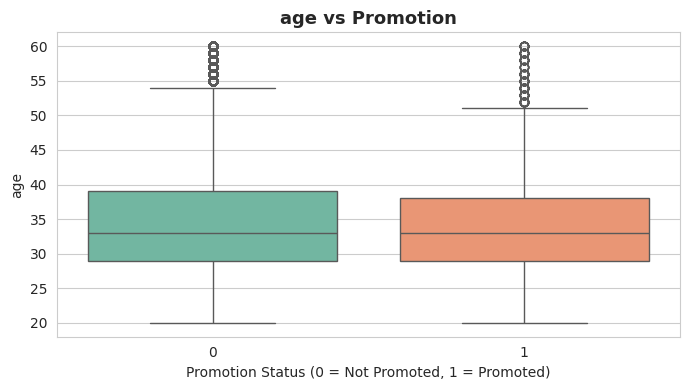

/tmp/ipykernel_45374/3064819863.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


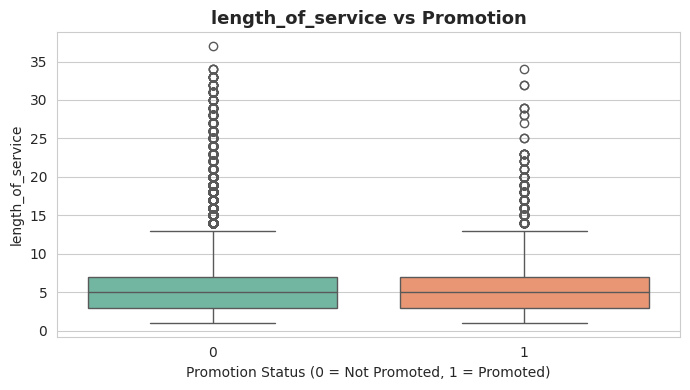

/tmp/ipykernel_45374/3064819863.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


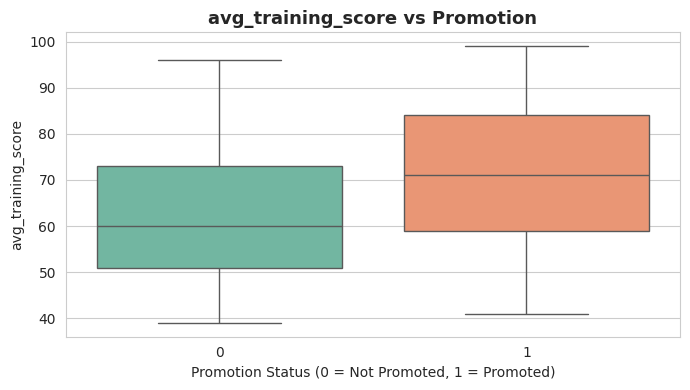

/tmp/ipykernel_45374/3064819863.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


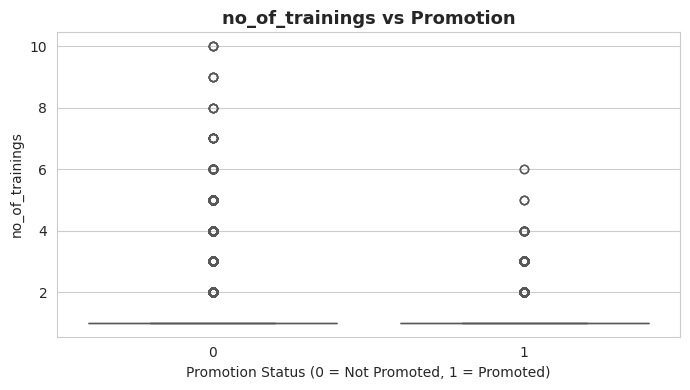

/tmp/ipykernel_45374/3064819863.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


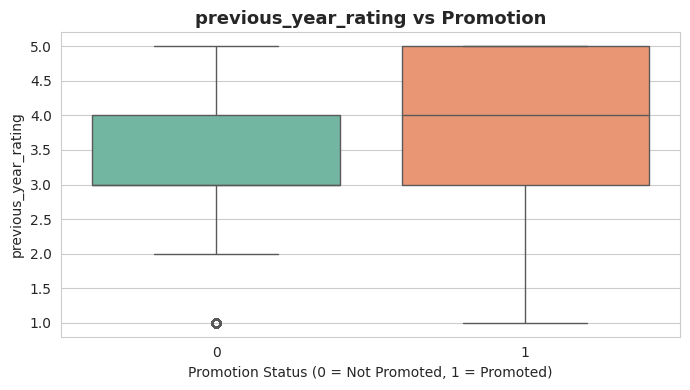

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

num_cols = ['age','length_of_service','avg_training_score','no_of_trainings','previous_year_rating']

for col in num_cols:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        x='is_promoted',
        y=col,
        data=df,
        palette="Set2"
    )

    plt.title(f'{col} vs Promotion', fontsize=13, fontweight='bold')
    plt.xlabel("Promotion Status (0 = Not Promoted, 1 = Promoted)")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

Observation

Employees who have won awards appear to have a higher proportion of promotions compared to employees without awards.

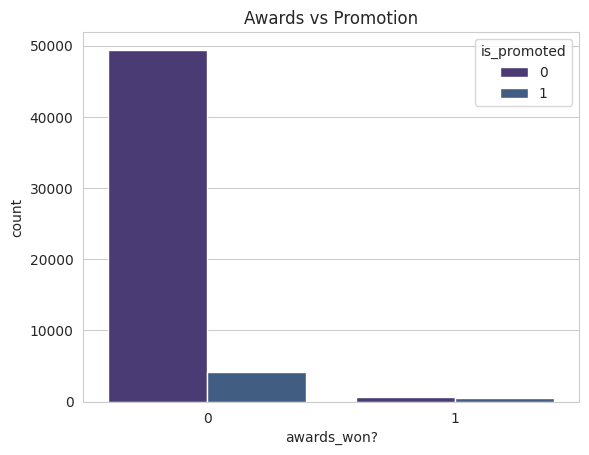

In [89]:
sns.countplot(x='awards_won?', hue='is_promoted', data=df)   #for the binary feature vs target 
plt.title('Awards vs Promotion')
plt.show()

Assumption

Awards are typically given to high-performing employees, which may increase their chances of being promoted.

Inference

The awards_won feature may be a strong predictor of promotion, as it likely reflects exceptional employee performance.

# Step 11 : Bivariate Analysis: Categorical Features vs Promotion

Observation

Count plots were generated to analyze the relationship between categorical variables and employee promotion status. The analysis shows that promotion distribution varies across categories such as department,gender, education level, recruitment channel, and region.

Some departments and regions exhibit higher promotion counts, indicating that organizational structure and workforce distribution may influence promotion opportunities.

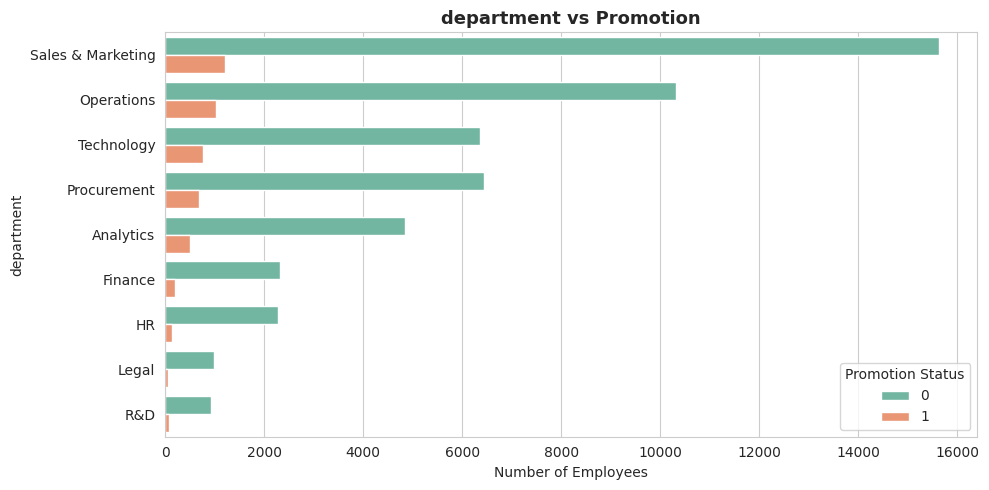

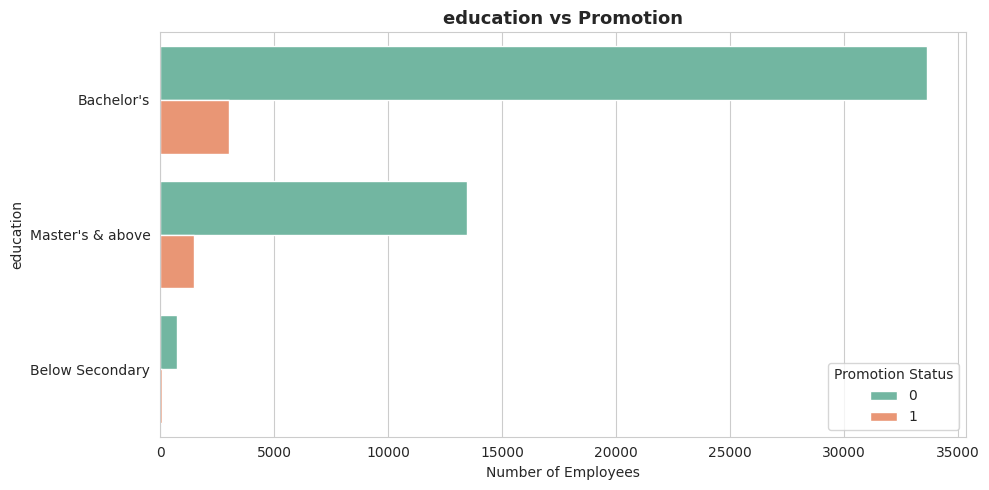

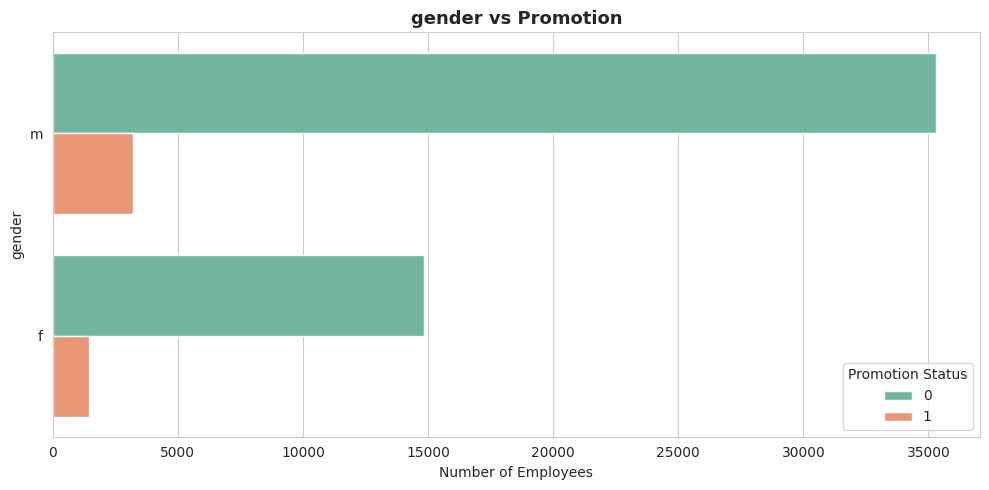

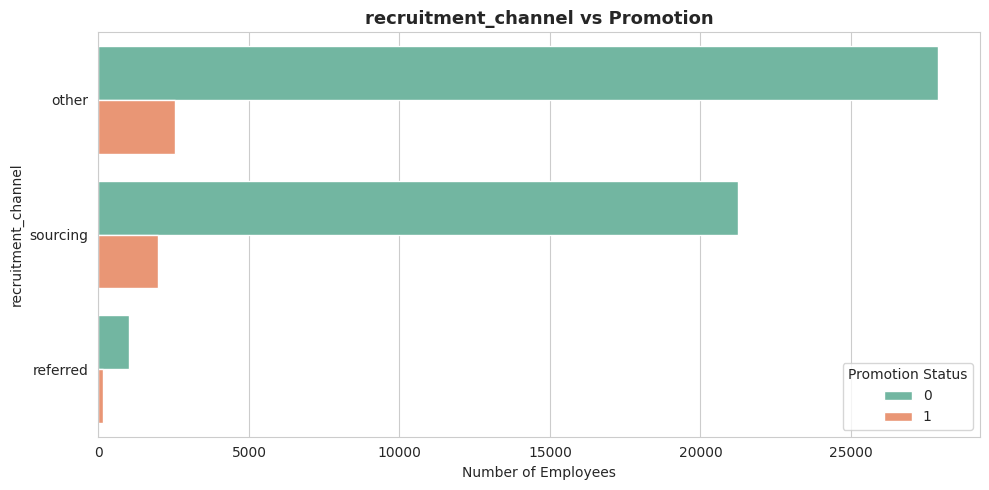

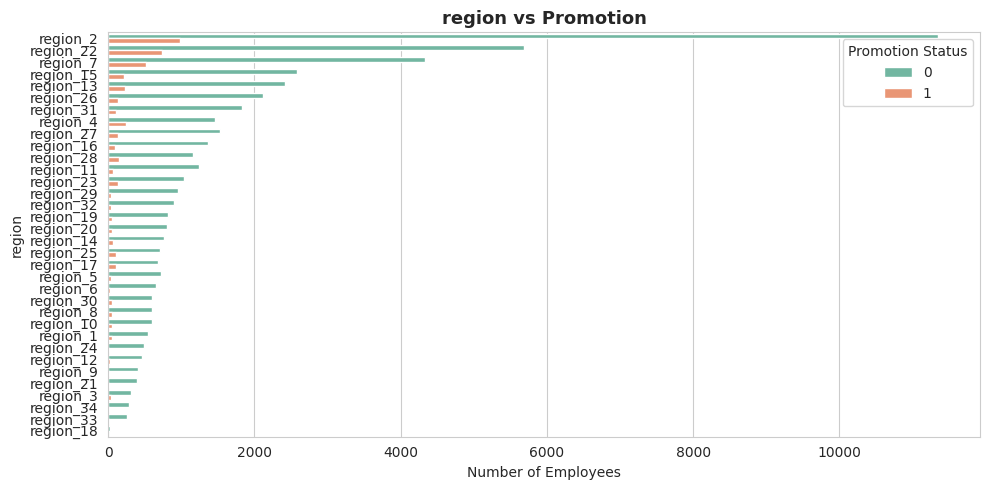

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

cat_cols = ['department','education','gender','recruitment_channel','region']

for col in cat_cols:

    plt.figure(figsize=(10,5))

    sns.countplot(
        data=df,
        y=col,
        hue='is_promoted',
        order=df[col].value_counts().index,
        palette="Set2"
    )

    plt.title(f"{col} vs Promotion", fontsize=13, fontweight="bold")
    plt.xlabel("Number of Employees")
    plt.ylabel(col)

    plt.legend(title="Promotion Status")

    plt.tight_layout()
    plt.show()

# Step12: multivariate analysis : for analysing multiple variables together 

Observation

A correlation heatmap was generated to analyze relationships between numerical variables. The matrix shows the strength and direction of linear relationships between features.

Certain variables such as average training score and previous year rating show positive correlation with the promotion variable, suggesting that employee performance indicators may influence promotion decisions.

Additionally, age and length of service show moderate correlation, which is expected as employees with higher age typically have longer tenure.

Text(0.5, 1.0, 'Correlation Matrix')

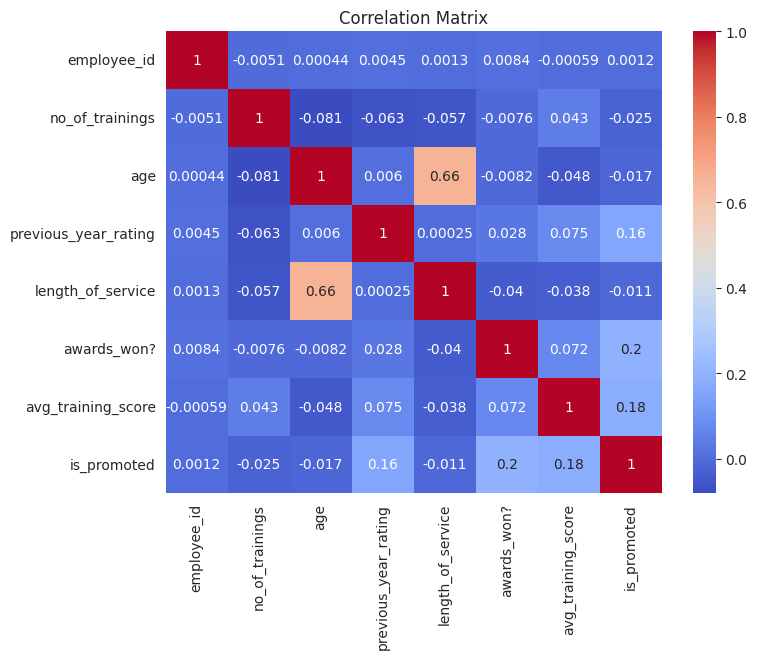

In [91]:
import seaborn as sns  # heatmap is used to detect multivariate

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix') 

Assumption

Performance-related variables such as training scores and performance ratings are likely to play a key role in promotion decisions.

Inference

Correlation analysis helps identify potentially important features for predictive modeling and highlights relationships between variables that may influence employee promotion outcomes.

# Step : Hypothesis testing 

## avg_training_score vs is_promoted (t-test) 

Observation

From the EDA plots, employees with higher average training scores appear more likely to be promoted.
Hypothesis:

Null Hypothesis (H₀): avg_training_score has no relationship with promotion.

Alternative Hypothesis (H₁): Alternative Hypothesis (H₁)

Hypothesis Test

Since:

avg_training_score → numerical
is_promoted → binary

We use t-test.


In [92]:
from scipy.stats import ttest_ind

promoted = df[df['is_promoted'] == 1]['avg_training_score']
not_promoted = df[df['is_promoted'] == 0]['avg_training_score']

stat, p = ttest_ind(promoted, not_promoted)

print("p-value:", p)


p-value: 0.0


## previous_year_rating vs is_promoted (t-test)
Observation

From the EDA analysis, employees with higher previous year ratings seem more likely to get promoted.

Hypothesis

Null Hypothesis (H₀):

previous_year_rating has no relationship with promotion.

Alternative Hypothesis (H₁):

previous_year_rating influences promotion.

it will give you the P-value 

p < 0.05 : reject H₀ : significant relationship
p ≥ 0.05 : fail to reject H₀ : no significant relationship

In [93]:
from scipy.stats import ttest_ind

promoted = df[df['is_promoted'] == 1]['previous_year_rating']
not_promoted = df[df['is_promoted'] == 0]['previous_year_rating']

stat, p = ttest_ind(promoted, not_promoted)

print("p-value:", p)

p-value: nan


# Gender Vs promotion (chi-square)

Observation
From EDA, promotion distribution appears similar across genders.

Hypothesis

H₀:Gender and promotion are independent.

H₁:Gender influences promotion.

In [94]:
from scipy.stats import chi2_contingency
import pandas as pd

table = pd.crosstab(df['gender'], df['is_promoted'])

chi2, p, dof, expected = chi2_contingency(table)

print("p-value:", p)

p-value: 0.009765091521176657


Inference rule

p < 0.05  → reject H₀ → significant relationship
p ≥ 0.05 → fail to reject H₀ → no significant relationship

# Awards Vs promotion (chi-square)
Observation

Employees who have won awards seem more likely to get promoted compared to those who have not.

Hypothesis

H₀ (Null Hypothesis)

awards_won? and promotion are independent

H₁ (Alternative Hypothesis)

awards_won? influences promotion


In [95]:
from scipy.stats import chi2_contingency
import pandas as pd

table = pd.crosstab(df['awards_won?'], df['is_promoted'])

chi2, p, dof, expected = chi2_contingency(table)

print("p-value:", p)

p-value: 0.0


Inference Rule: 
p<0.5 :  significant relationship
p>=0.5 : no significant relationship

# Department Vs promotion(chi-square)
Observation

From EDA, promotion rates appear different across departments, suggesting department might influence promotion decisions.

H₀ (Null Hypothesis): Department and promotion are independent.
H₁ (Alternative Hypothesis): Department influences promotion.

In [96]:
from scipy.stats import chi2_contingency
import pandas as pd

table = pd.crosstab(df['department'], df['is_promoted'])

chi2, p, dof, expected = chi2_contingency(table)

print("p-value:", p)

p-value: 9.882497107474632e-29


Inference Rule: 
p<0.5 :  significant relationship
p>=0.5 : no significant relationship

# Education Vs promotion (chi-square)
Observation

From EDA, promotion rates appear different education, suggesting education might influence promotion decisions.

In [97]:
from scipy.stats import chi2_contingency
import pandas as pd

table = pd.crosstab(df['education'], df['is_promoted'])

chi2, p, dof, expected = chi2_contingency(table)

print("p-value:", p)

p-value: 1.0716517784616584e-08


Inference Rule: 
p<0.5 :  significant relationship
p>=0.5 : no significant relationship

# Gender Vs promotion (chi-square)
Observation

From EDA, promotion rates appear gender, suggesting gender might influence promotion decisions.

In [98]:
from scipy.stats import chi2_contingency
import pandas as pd

table = pd.crosstab(df['gender'], df['is_promoted'])

chi2, p, dof, expected = chi2_contingency(table)

print("p-value:", p)

p-value: 0.009765091521176657


Inference Rule: 
p<0.5 :  significant relationship
p>=0.5 : no significant relationship

# Recruiment_channel Vs promotion (chi-square)
Observation

From EDA, promotion rates appear gender, suggesting gender might influence promotion decisions.

In [99]:
from scipy.stats import chi2_contingency
import pandas as pd

table = pd.crosstab(df['recruitment_channel'], df['is_promoted'])

chi2, p, dof, expected = chi2_contingency(table)

print("p-value:", p)

p-value: 6.650937825577018e-05


Inference Rule: 
p<0.5 :  significant relationship
p>=0.5 : no significant relationship

In [100]:
import pandas as pd    # for detecting the outliers 

numeric_cols = df.select_dtypes(include=['int64','float64'])

Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)

IQR = Q3 - Q1

outliers = ((numeric_cols < (Q1 - 1.5*IQR)) | 
            (numeric_cols > (Q3 + 1.5*IQR)))

outliers.sum()

employee_id                 0
no_of_trainings         10430
age                      1435
previous_year_rating     6223
length_of_service        3489
awards_won?              1270
avg_training_score          0
is_promoted              4668
dtype: int64

Conclusion : There are 54808 rows and 13 col in the data in which there are no duplicates in which length of service and no_of_training is almost right skewed. 
Then the box plot analysis show that there are several statistical outliers like age , number of training , and length of training . while some detected due to discrete or categorical variables like awards won and is_promoted so boxplot can determine this all as the incorrect outliers .
in department there more number of counts in sales and marketing team there are more number of people of region 2, most of the people has done bachelors ,there are more number of male there so for the target variable we have to do feature selection as some of them are no in necessary.
then no of training , length of service , is highly skewed and need to be transformed , age is moderated skewed so it needs transformation.
After doing bivariate it tells that age does not influence promotion , length of service influence to the promotion but does not make very large difference , avg training score highly influences promotion , previous year rating highly influences the promotion.
The analysis shows that most employees did not receive awards. However, employees who won awards have a higher likelihood of being promoted compared to those who did not win awards, indicating that awards may positively influence promotion decisions.

In categorical data : The dataset shows variation in promotions across departments, education levels, recruitment channels, and regions. Most employees belong to Sales & Marketing and Operations departments, hold Bachelor’s degrees, and were recruited through sourcing or other channels. Promotions occur across all categories but remain relatively limited compared to the total number of employees. 

Missing values : for education we will the impute the data using Mode imputation 
and for the previous year ratings we can use median imputation. 

outliers : we can use use capping for limmiting the values.

skewness: 
we will use log , square_root transformation so that after the transformation it becomes managable 

encoding: 
one-hot encoding ,binary ,ordinal encoding 




Handling missing values 


In [101]:
df['education'].fillna(df['education'].mode()[0], inplace=True)


/tmp/ipykernel_45374/2912846660.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['education'].fillna(df['education'].mode()[0], inplace=True)


In [102]:
df['previous_year_rating'].fillna(df['previous_year_rating'].median(), inplace=True)


/tmp/ipykernel_45374/935552105.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['previous_year_rating'].fillna(df['previous_year_rating'].median(), inplace=True)


In [103]:
df.isnull().sum()

employee_id             0
department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
awards_won?             0
avg_training_score      0
is_promoted             0
dtype: int64

removing outliers 


In [104]:
df

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54803,3030,Technology,region_14,Bachelor's,m,sourcing,1,48,3.0,17,0,78,0
54804,74592,Operations,region_27,Master's & above,f,other,1,37,2.0,6,0,56,0
54805,13918,Analytics,region_1,Bachelor's,m,other,1,27,5.0,3,0,79,0
54806,13614,Sales & Marketing,region_9,Bachelor's,m,sourcing,1,29,1.0,2,0,45,0


In [105]:
num_cols = ['age','length_of_service','avg_training_score','no_of_trainings','previous_year_rating']  #for the outliers

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df[num_cols] = df[num_cols].clip(lower, upper, axis=1)

In [106]:
df[num_cols].describe() #we can see that if the outliers have transformed in a proper range or not. 

,age,length_of_service,avg_training_score,no_of_trainings,previous_year_rating
count,54808.000000,54808.000000,54808.000000,54808.0,54808.000000
mean,34.717523,5.570829,63.386750,1.0,3.361252
std,7.415531,3.414373,13.371559,0.0,1.113180
min,20.000000,1.000000,39.000000,1.0,1.500000
25%,29.000000,3.000000,51.000000,1.0,3.000000
50%,33.000000,5.000000,60.000000,1.0,3.000000
75%,39.000000,7.000000,76.000000,1.0,4.000000
max,54.000000,13.000000,99.000000,1.0,5.000000


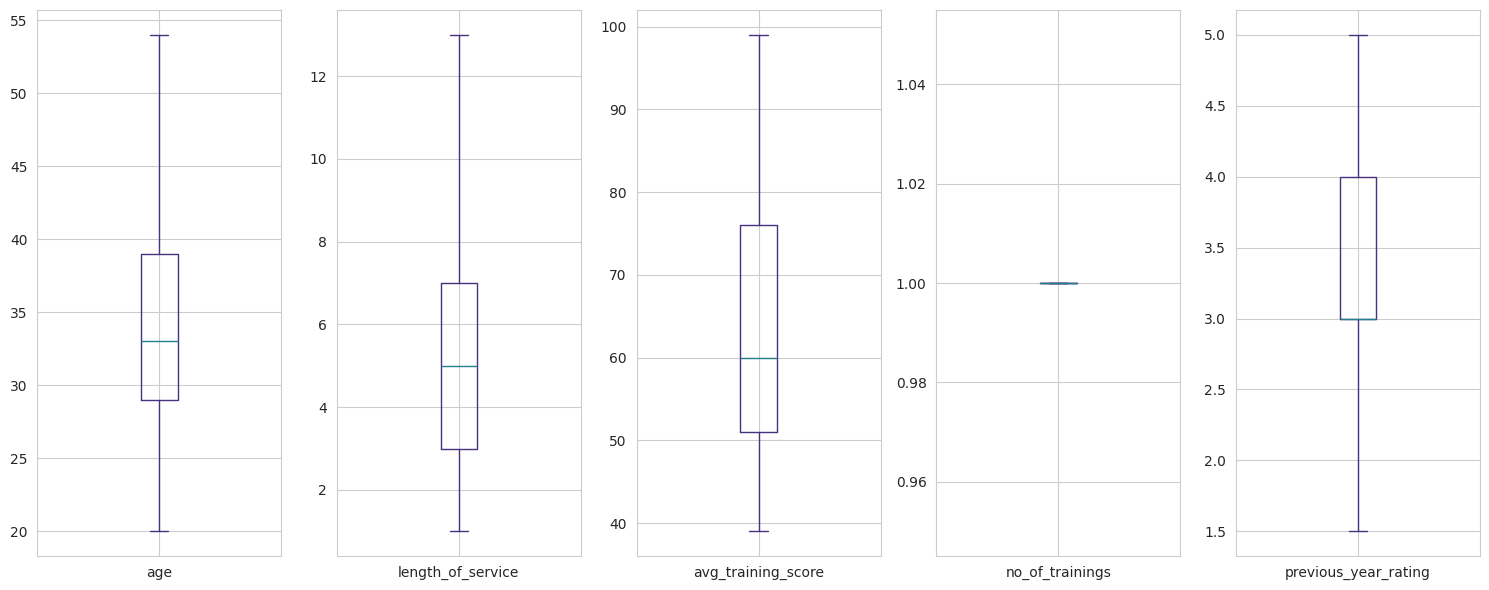

In [107]:
df[num_cols].plot(kind='box', subplots=True, figsize=(15, 6))  #box plot of detecting the outliers and the spread of the data 
plt.tight_layout()
plt.show()

In [108]:
test = pd.read_csv("test.csv")   
test

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,61
...,...,...,...,...,...,...,...,...,...,...,...,...
23485,53478,Legal,region_2,Below Secondary,m,sourcing,1,24,3.0,1,0,61
23486,25600,Technology,region_25,Bachelor's,m,sourcing,1,31,3.0,7,0,74
23487,45409,HR,region_16,Bachelor's,f,sourcing,1,26,4.0,4,0,50
23488,1186,Procurement,region_31,Bachelor's,m,sourcing,3,27,NaN,1,0,70


In [109]:
test.isnull().sum()

employee_id                0
department                 0
region                     0
education               1034
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    1812
length_of_service          0
awards_won?                0
avg_training_score         0
dtype: int64

In [110]:
test['education'].fillna(test['education'].mode()[0], inplace=True)  
test['previous_year_rating'].fillna(test['previous_year_rating'].median(), inplace=True)


/tmp/ipykernel_45374/2279496884.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['education'].fillna(test['education'].mode()[0], inplace=True)
/tmp/ipykernel_45374/2279496884.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

In [111]:
test.isnull().sum()

employee_id             0
department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
awards_won?             0
avg_training_score      0
dtype: int64

In [112]:
num_cols = ['age','length_of_service','avg_training_score','no_of_trainings','previous_year_rating']  #for transforming the outliers

Q1 = test[num_cols].quantile(0.25)
Q3 = test[num_cols].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

test[num_cols] = test[num_cols].clip(lower, upper, axis=1)

In [113]:
test[num_cols].describe() #we can see that if the outliers have transformed in a proper range or not. 

,age,length_of_service,avg_training_score,no_of_trainings,previous_year_rating
count,23490.000000,23490.000000,23490.000000,23490.0,23490.00000
mean,34.696637,5.527927,63.263133,1.0,3.37003
std,7.435866,3.395109,13.411750,0.0,1.11461
min,20.000000,1.000000,39.000000,1.0,1.50000
25%,29.000000,3.000000,51.000000,1.0,3.00000
50%,33.000000,5.000000,60.000000,1.0,3.00000
75%,39.000000,7.000000,76.000000,1.0,4.00000
max,54.000000,13.000000,99.000000,1.0,5.00000


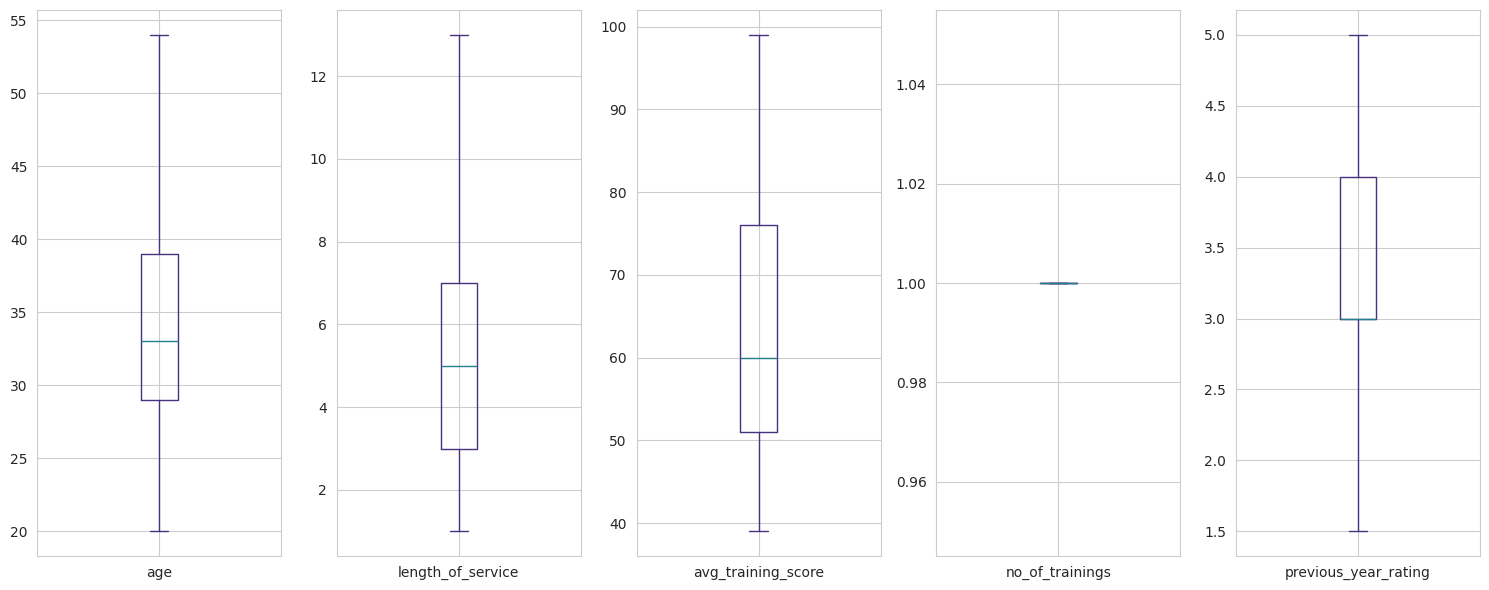

In [114]:
test[num_cols].plot(kind='box', subplots=True, figsize=(15, 6))  #box plot of detecting the outliers and the spread of the data 
plt.tight_layout()
plt.show()

In [115]:
df[num_cols].skew()  #As I performed capping previously so the skewness is automatically reduced

age                     0.855553
length_of_service       0.705358
avg_training_score      0.451908
no_of_trainings         0.000000
previous_year_rating    0.031615
dtype: float64

In [116]:
test[num_cols].skew()

age                     0.862398
length_of_service       0.722602
avg_training_score      0.458113
no_of_trainings         0.000000
previous_year_rating    0.020434
dtype: float64

encoding data 


In [117]:
df['gender'] = df['gender'].map({'m':1,'f':0})  # we have used binary encoding here


In [118]:
df

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,0,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,1,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,1,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,1,other,1,39,1.5,10,0,50,0
4,48945,Technology,region_26,Bachelor's,1,other,1,45,3.0,2,0,73,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54803,3030,Technology,region_14,Bachelor's,1,sourcing,1,48,3.0,13,0,78,0
54804,74592,Operations,region_27,Master's & above,0,other,1,37,2.0,6,0,56,0
54805,13918,Analytics,region_1,Bachelor's,1,other,1,27,5.0,3,0,79,0
54806,13614,Sales & Marketing,region_9,Bachelor's,1,sourcing,1,29,1.5,2,0,45,0


In [119]:
df["education"].value_counts()

education
Bachelor's          39078
Master's & above    14925
Below Secondary       805
Name: count, dtype: int64

In [120]:
#as the education data is ordinal we can use ordinal encoding 
education_map = {
    'Below Secondary':0,
    "Bachelor's":1,
    "Master's & above":2
}

df['education'] = df['education'].map(education_map)

In [121]:
df["education"].value_counts()

education
1    39078
2    14925
0      805
Name: count, dtype: int64

In [122]:
df

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,2,0,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,1,1,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,1,1,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,1,1,other,1,39,1.5,10,0,50,0
4,48945,Technology,region_26,1,1,other,1,45,3.0,2,0,73,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54803,3030,Technology,region_14,1,1,sourcing,1,48,3.0,13,0,78,0
54804,74592,Operations,region_27,2,0,other,1,37,2.0,6,0,56,0
54805,13918,Analytics,region_1,1,1,other,1,27,5.0,3,0,79,0
54806,13614,Sales & Marketing,region_9,1,1,sourcing,1,29,1.5,2,0,45,0


In [123]:
#now we would perform one hot encoding for the nominal data 


In [124]:
df = pd.get_dummies(
    df,
    columns=['department','region','recruitment_channel'],
    drop_first=True
)

In [126]:
df

,employee_id,education,gender,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted,...,region_region_33,region_region_34,region_region_4,region_region_5,region_region_6,region_region_7,region_region_8,region_region_9,recruitment_channel_referred,recruitment_channel_sourcing
0,65438,2,0,1,35,5.0,8,0,49,0,...,False,False,False,False,False,True,False,False,False,True
1,65141,1,1,1,30,5.0,4,0,60,0,...,False,False,False,False,False,False,False,False,False,False
2,7513,1,1,1,34,3.0,7,0,50,0,...,False,False,False,False,False,False,False,False,False,True
3,2542,1,1,1,39,1.5,10,0,50,0,...,False,False,False,False,False,False,False,False,False,False
4,48945,1,1,1,45,3.0,2,0,73,0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54803,3030,1,1,1,48,3.0,13,0,78,0,...,False,False,False,False,False,False,False,False,False,True
54804,74592,2,0,1,37,2.0,6,0,56,0,...,False,False,False,False,False,False,False,False,False,False
54805,13918,1,1,1,27,5.0,3,0,79,0,...,False,False,False,False,False,False,False,False,False,False
54806,13614,1,1,1,29,1.5,2,0,45,0,...,False,False,False,False,False,False,False,True,False,True


In [138]:
#df = df.drop('employee_id', axis=1)
df


,education,gender,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted,department_Finance,...,region_region_33,region_region_34,region_region_4,region_region_5,region_region_6,region_region_7,region_region_8,region_region_9,recruitment_channel_referred,recruitment_channel_sourcing
0,2,0,1,35,5.0,8,0,49,0,False,...,False,False,False,False,False,True,False,False,False,True
1,1,1,1,30,5.0,4,0,60,0,False,...,False,False,False,False,False,False,False,False,False,False
2,1,1,1,34,3.0,7,0,50,0,False,...,False,False,False,False,False,False,False,False,False,True
3,1,1,1,39,1.5,10,0,50,0,False,...,False,False,False,False,False,False,False,False,False,False
4,1,1,1,45,3.0,2,0,73,0,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54803,1,1,1,48,3.0,13,0,78,0,False,...,False,False,False,False,False,False,False,False,False,True
54804,2,0,1,37,2.0,6,0,56,0,False,...,False,False,False,False,False,False,False,False,False,False
54805,1,1,1,27,5.0,3,0,79,0,False,...,False,False,False,False,False,False,False,False,False,False
54806,1,1,1,29,1.5,2,0,45,0,False,...,False,False,False,False,False,False,False,True,False,True


# Feature Selection

In [139]:
X = df.drop('is_promoted', axis=1)
y = df['is_promoted']

In [140]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

selector = SelectKBest(score_func=chi2, k=15)
X_filtered = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
print(selected_features)

Index(['age', 'previous_year_rating', 'awards_won?', 'avg_training_score',
       'department_HR', 'department_Sales & Marketing',
       'department_Technology', 'region_region_17', 'region_region_22',
       'region_region_29', 'region_region_31', 'region_region_32',
       'region_region_4', 'region_region_7', 'region_region_9'],
      dtype='object')


In [145]:
#wrapper method 
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

rfe = RFE(model, n_features_to_select=10)
X_rfe = rfe.fit_transform(X, y)

selected_features_rfe = X.columns[rfe.support_]
print(selected_features_rfe)

Index(['gender', 'age', 'previous_year_rating', 'length_of_service',
       'awards_won?', 'avg_training_score', 'department_Operations',
       'department_Sales & Marketing', 'region_region_2',
       'recruitment_channel_sourcing'],
      dtype='object')


In [144]:
model.fit(X, y)

import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance)

                         Feature  Importance
7             avg_training_score    0.344679
3                            age    0.168362
5              length_of_service    0.128598
4           previous_year_rating    0.057482
6                    awards_won?    0.031653
50  recruitment_channel_sourcing    0.031633
14  department_Sales & Marketing    0.024873
1                         gender    0.024288
11         department_Operations    0.020389
0                      education    0.018377
12        department_Procurement    0.011656
26               region_region_2    0.010304
15         department_Technology    0.009896
8             department_Finance    0.007641
46               region_region_7    0.006516
21              region_region_15    0.005885
29              region_region_22    0.005816
19              region_region_13    0.005635
49  recruitment_channel_referred    0.005417
34              region_region_27    0.004785
33              region_region_26    0.004746
9         